# MNIST handwritten-digit classifier

A feed-forward neural network that classifies 28x28 grayscale images of handwritten
digits (0-9) from the classic **MNIST** dataset, built with TensorFlow / Keras.

This notebook follows a simple 5-step plan:

1. **Prepare the data** - load, normalize, and split into training / validation / test sets
2. **Outline the model** - choose the layers and activation functions
3. **Set the optimizer and loss**
4. **Train** the model
5. **Test** its accuracy on unseen data

> Built as a learning project while working through the deep-learning section of a
> data-science course. Each step includes a short note on *why*, not just *how*.

## 0. Imports and setup

We fix the random seeds so the run is reproducible - anyone who runs this notebook
should get the same results.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Reproducibility: fix the random seeds so results are repeatable
np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## 1. Prepare the data (load, normalize, split)

MNIST ships with Keras. Each image is 28x28 pixels, each pixel an integer 0-255.

In [3]:
mnist_dataset, mnist_info = tfds.load(
    name='mnist',
    with_info=True,
    as_supervised=True,
    builder_kwargs={'file_format': 'tfrecord'},
)

## according to mnist documentation, the train is around 60k values and test is around 10k
mnist_train,mnist_test = mnist_dataset['train'], mnist_dataset['test']

num_validation_samples = 0.1 * mnist_info.splits['train'].num_examples
num_validation_samples = tf.cast(num_validation_samples, tf.int64)

num_test_samples = mnist_info.splits['test'].num_examples
num_test_samples = tf.cast(num_test_samples, tf.int64)

def scale(image,label):
    image = tf.cast(image, tf.float32)
    image /= 255. ## the . basically says we need it to be a float
    return image, label

scaled_train_and_validation_data = mnist_train.map(scale)
test_data = mnist_test.map(scale)

## shuffling the data, we need it as random as possible

BUFFER_SIZE = 10000
shuffled_train_and_validation_data = scaled_train_and_validation_data.shuffle(BUFFER_SIZE)

validation_data = shuffled_train_and_validation_data.take(num_validation_samples)
train_data = shuffled_train_and_validation_data.skip(num_validation_samples)

BATCH_SIZE = 100

train_data = train_data.batch(BATCH_SIZE)
validation_data = validation_data.batch(num_validation_samples)
test_data = test_data.batch(num_test_samples)

validation_inputs , validation_targets = next(iter(validation_data))

## 2. Outline the model and choose activations

In [31]:
input_size = 784 # 28 * 28
output_size = 10
hidden_layer_size = 100

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape = (28,28,1)),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(hidden_layer_size, activation='relu'),
    tf.keras.layers.Dense(output_size, activation='softmax')
])
                            

## 3. Set the optimizer and loss

- **Adam** - momentum + adaptive per-weight step sizes; the practical default optimizer.
- **Cross-entropy loss** - the standard loss for classification. We use the `sparse_`
  version because our labels are integers (0-9), not one-hot vectors.

In [32]:
model.compile(optimizer = 'adam', loss = 'sparse_categorical_crossentropy', metrics = ['accuracy'])                                                                            

## 4. Make it learn

**Early stopping** watches the validation loss and halts when it stops improving,
restoring the best weights. This guards against overfitting (memorizing noise) and
saves us from guessing the exact number of epochs.

In [33]:
NUM_EPOCHS = 50
early_stopping = tf.keras.callbacks.EarlyStopping(patience=2, restore_best_weights=True)

model.fit(train_data, epochs = NUM_EPOCHS, callbacks = [early_stopping], validation_data = (validation_inputs , validation_targets), verbose = 2)

Epoch 1/50
540/540 - 3s - 5ms/step - accuracy: 0.9058 - loss: 0.3304 - val_accuracy: 0.9555 - val_loss: 0.1546
Epoch 2/50
540/540 - 2s - 4ms/step - accuracy: 0.9590 - loss: 0.1377 - val_accuracy: 0.9672 - val_loss: 0.1035
Epoch 3/50
540/540 - 2s - 3ms/step - accuracy: 0.9709 - loss: 0.0957 - val_accuracy: 0.9758 - val_loss: 0.0800
Epoch 4/50
540/540 - 2s - 3ms/step - accuracy: 0.9773 - loss: 0.0740 - val_accuracy: 0.9773 - val_loss: 0.0722
Epoch 5/50
540/540 - 2s - 3ms/step - accuracy: 0.9815 - loss: 0.0594 - val_accuracy: 0.9812 - val_loss: 0.0597
Epoch 6/50
540/540 - 2s - 3ms/step - accuracy: 0.9852 - loss: 0.0469 - val_accuracy: 0.9847 - val_loss: 0.0529
Epoch 7/50
540/540 - 2s - 3ms/step - accuracy: 0.9881 - loss: 0.0394 - val_accuracy: 0.9848 - val_loss: 0.0464
Epoch 8/50
540/540 - 2s - 3ms/step - accuracy: 0.9888 - loss: 0.0343 - val_accuracy: 0.9858 - val_loss: 0.0411
Epoch 9/50
540/540 - 2s - 3ms/step - accuracy: 0.9910 - loss: 0.0285 - val_accuracy: 0.9908 - val_loss: 0.0344
E

## 5. Test the accuracy

The honest final score, measured on the test set the model has never seen.

In [34]:
test_loss, test_accuracy = model.evaluate(test_data)
print('Test loss : {0:.2f}. Test accuracy: {1:.2f}'.format(test_loss,test_accuracy*100.))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step - accuracy: 0.9773 - loss: 0.0865
Test loss : 0.09. Test accuracy: 97.73


## Adding confusion matrix as an extra step for additional learnability on my end

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


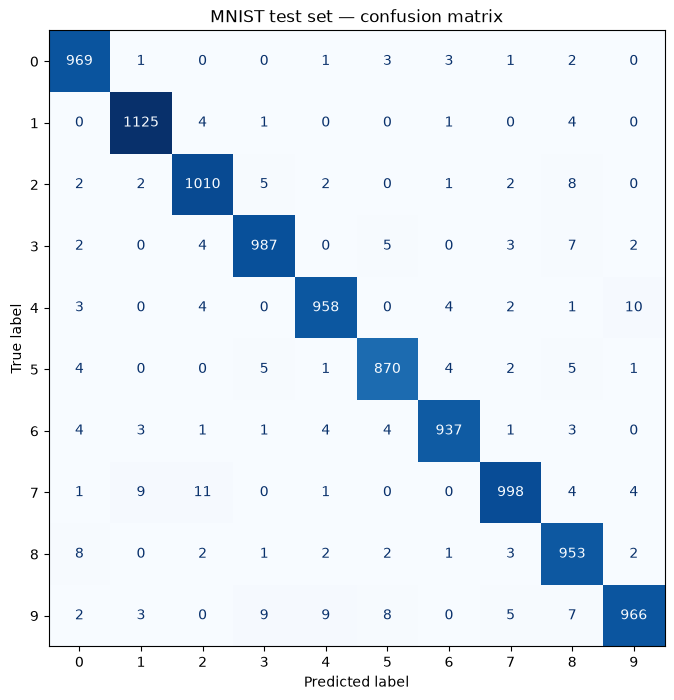

In [35]:
# Pull the whole test set as one batch, then get the model's predictions
test_inputs, test_targets = next(iter(test_data))       # one batch = all 10,000 test images + labels
predicted_probs = model.predict(test_inputs)            # shape (10000, 10): a softmax prob per digit
predicted_labels = np.argmax(predicted_probs, axis=1)   # the model's pick = the highest-probability digit

# Confusion matrix: rows = the TRUE digit, columns = what the model PREDICTED
cm = confusion_matrix(test_targets.numpy(), predicted_labels)

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10)).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('MNIST test set — confusion matrix')
plt.show()

## What I learned

- The full supervised-learning workflow end to end: preprocess -> model -> optimize -> train -> evaluate.
- **Why** each choice is made: normalization for stable training, a held-out validation
  set to detect overfitting, ReLU vs softmax activations, cross-entropy for classification,
  Adam as the optimizer, and early stopping to halt at the right time.
- How to read training vs validation curves and a confusion matrix to judge a model.

### Tuning experiments

Starting from a baseline, I changed **one thing at a time** and recorded the validation
accuracy, so I could tell which change was responsible for which result.

| # | Change | Validation accuracy |
|---|--------|:-------------------:|
| 0 | Baseline: 2 hidden layers, 5 epochs, no early stopping | ~98.0% |
| 1 | More epochs (50) + early stopping | **99.35%** |
| 2 | Wider hidden layers | 99.13% |
| 3 | Added a 3rd hidden layer (deeper) | 99.02% |
| 4 | Reverted to the best-performing config | **99.47%** |

Final honest score on the untouched **test set: 97.73%** — the number that actually counts.

**What the experiments taught me**

- The biggest win came from **training longer with early stopping**, not from a bigger
  network - training time was the knob with the most headroom left.
- Making the network **wider or deeper both slightly *hurt***. For MNIST with a simple
  feed-forward net, the model already had enough capacity, so extra capacity just gave it
  more room to overfit. A change that makes things *worse* is still a useful, reportable result.
- **Run-to-run variance is real** (~0.1-0.2%): the data is reshuffled every run, so tiny
  differences between configs aren't always meaningful.
- The **validation-to-test gap** (99.47% -> 97.73%) is expected: I tuned against validation,
  so it grew slightly optimistic; the test set, touched once, gives the honest figure.

*Next ideas: add dropout, compare optimizers, or move to a convolutional network (CNN) -
the natural next step for image data.*